## Mount Google Drive



In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Import Libraries

In [2]:
import os
import cv2
import pandas as pd
import numpy as np
from PIL import Image
from tqdm import tqdm
import matplotlib.pyplot as plt
import torch
from torchvision import transforms

## Setup

In [3]:
# RAW DATASET FOLDER
IMG_PARENT_DIR = '/content/drive/MyDrive/Wound_Assessment/Extracted_Images'
PUBLIC_IMG_DIR = os.path.join(IMG_PARENT_DIR, 'Public_Dataset')
PRIVATE_IMG_DIR = os.path.join(IMG_PARENT_DIR, 'Real_World_Dataset')

# SEGMENTED DATASET
MASK_DIR = '/content/drive/MyDrive/Wound_Assessment/TSegNet_Masks_v2'
PROPOSED_IMG_DIR = '../data/segmented_images/Segmented_Dataset_Final_v2'
CSV_PATH = '../data/metadata/metadata_with_folds.csv'

df = pd.read_csv(CSV_PATH)
print(f"Found {len(df)} total images.")
print(df.head())

os.makedirs(PROPOSED_IMG_DIR, exist_ok=True)
print(f'Segmented output folder: {PROPOSED_IMG_DIR}')

Found 107 total images.
          filename  Final_Inf  Final_Moist  Final_Edge original_folder  \
0  wound001_01.jpg          0            1           1        wound001   
1  wound001_02.jpg          0            1           1        wound001   
2  wound001_03.jpg          0            1           1        wound001   
3  wound002_01.jpg          0            0          -1        wound002   
4  wound002_02.jpg          0            0          -1        wound002   

   Wound_ID                                    full_image_path  fold  
0  wound001  /content/drive/MyDrive/Wound_Assessment/Extrac...     0  
1  wound001  /content/drive/MyDrive/Wound_Assessment/Extrac...     0  
2  wound001  /content/drive/MyDrive/Wound_Assessment/Extrac...     0  
3  wound002  /content/drive/MyDrive/Wound_Assessment/Extrac...     1  
4  wound002  /content/drive/MyDrive/Wound_Assessment/Extrac...     1  
Segmented output folder: /content/drive/MyDrive/Wound_Assessment/Segmented_Dataset_Final_v3


## Preprocessing

### Resize with Padding

In [4]:
TARGET_SIZE = 224

def resize_with_padding(image, target_size=224):
    h, w = image.shape[:2]
    scale = min(target_size / w, target_size / h)
    new_w, new_h = int(w * scale), int(h * scale)
    resized = cv2.resize(image, (new_w, new_h), interpolation=cv2.INTER_CUBIC)
    canvas = np.zeros((target_size, target_size, 3), dtype=np.uint8)
    x_off, y_off = (target_size - new_w) // 2, (target_size - new_h) // 2
    canvas[y_off:y_off+new_h, x_off:x_off+new_w] = resized
    return canvas


def find_image_path(base_name):
    """Checks both Public and Private directories for the original image."""
    possible_paths = [
        os.path.join(PRIVATE_IMG_DIR, base_name + ".jpg"),
        os.path.join(PRIVATE_IMG_DIR, base_name + ".png"),
        os.path.join(PUBLIC_IMG_DIR, base_name + ".jpg"),
        os.path.join(PUBLIC_IMG_DIR, base_name + ".png")
    ]
    for path in possible_paths:
        if os.path.exists(path):
            return path
    return None

### Segmentation Builder

In [5]:
count = 0
for idx, row in tqdm(df.iterrows(), total=len(df)):
    filename = str(row['filename']).strip()
    base_name = os.path.splitext(filename)[0]

    # 1. Check all possible locations and extensions
    img_path = find_image_path(base_name)
    if img_path is None: continue

    # 2. MASK SEARCH
    mask_path = os.path.join(MASK_DIR, base_name + ".png")

    if img_path is None or not os.path.exists(mask_path):
        continue

    # 3. PROCESSING
    img = cv2.imread(img_path)
    mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
    if img is None or mask is None: continue

    # Match sizes
    if img.shape[:2] != mask.shape[:2]:
        mask = cv2.resize(mask, (img.shape[1], img.shape[0]), interpolation=cv2.INTER_NEAREST)

    # Background Suppression
    masked_img = cv2.bitwise_and(img, cv2.cvtColor(mask, cv2.COLOR_GRAY2BGR))

    # Crop to BBox
    rows, cols = np.any(mask, axis=1), np.any(mask, axis=0)
    if not np.any(rows) or not np.any(cols): continue
    y_min, y_max = np.where(rows)[0][[0, -1]]
    x_min, x_max = np.where(cols)[0][[0, -1]]

    # Final Resize (to TARGET_SIZE=224)
    final_output = resize_with_padding(masked_img[y_min:y_max, x_min:x_max], TARGET_SIZE)

    # Save (Keep original filename from CSV for consistency)
    cv2.imwrite(os.path.join(PROPOSED_IMG_DIR, filename), final_output)
    count += 1

print(f"\n Processed images are saved in: {PROPOSED_IMG_DIR}")

100%|██████████| 107/107 [01:37<00:00,  1.09it/s]


 Processed images are saved in: /content/drive/MyDrive/Wound_Assessment/Segmented_Dataset_Final_v3


## Visualize Processed Images

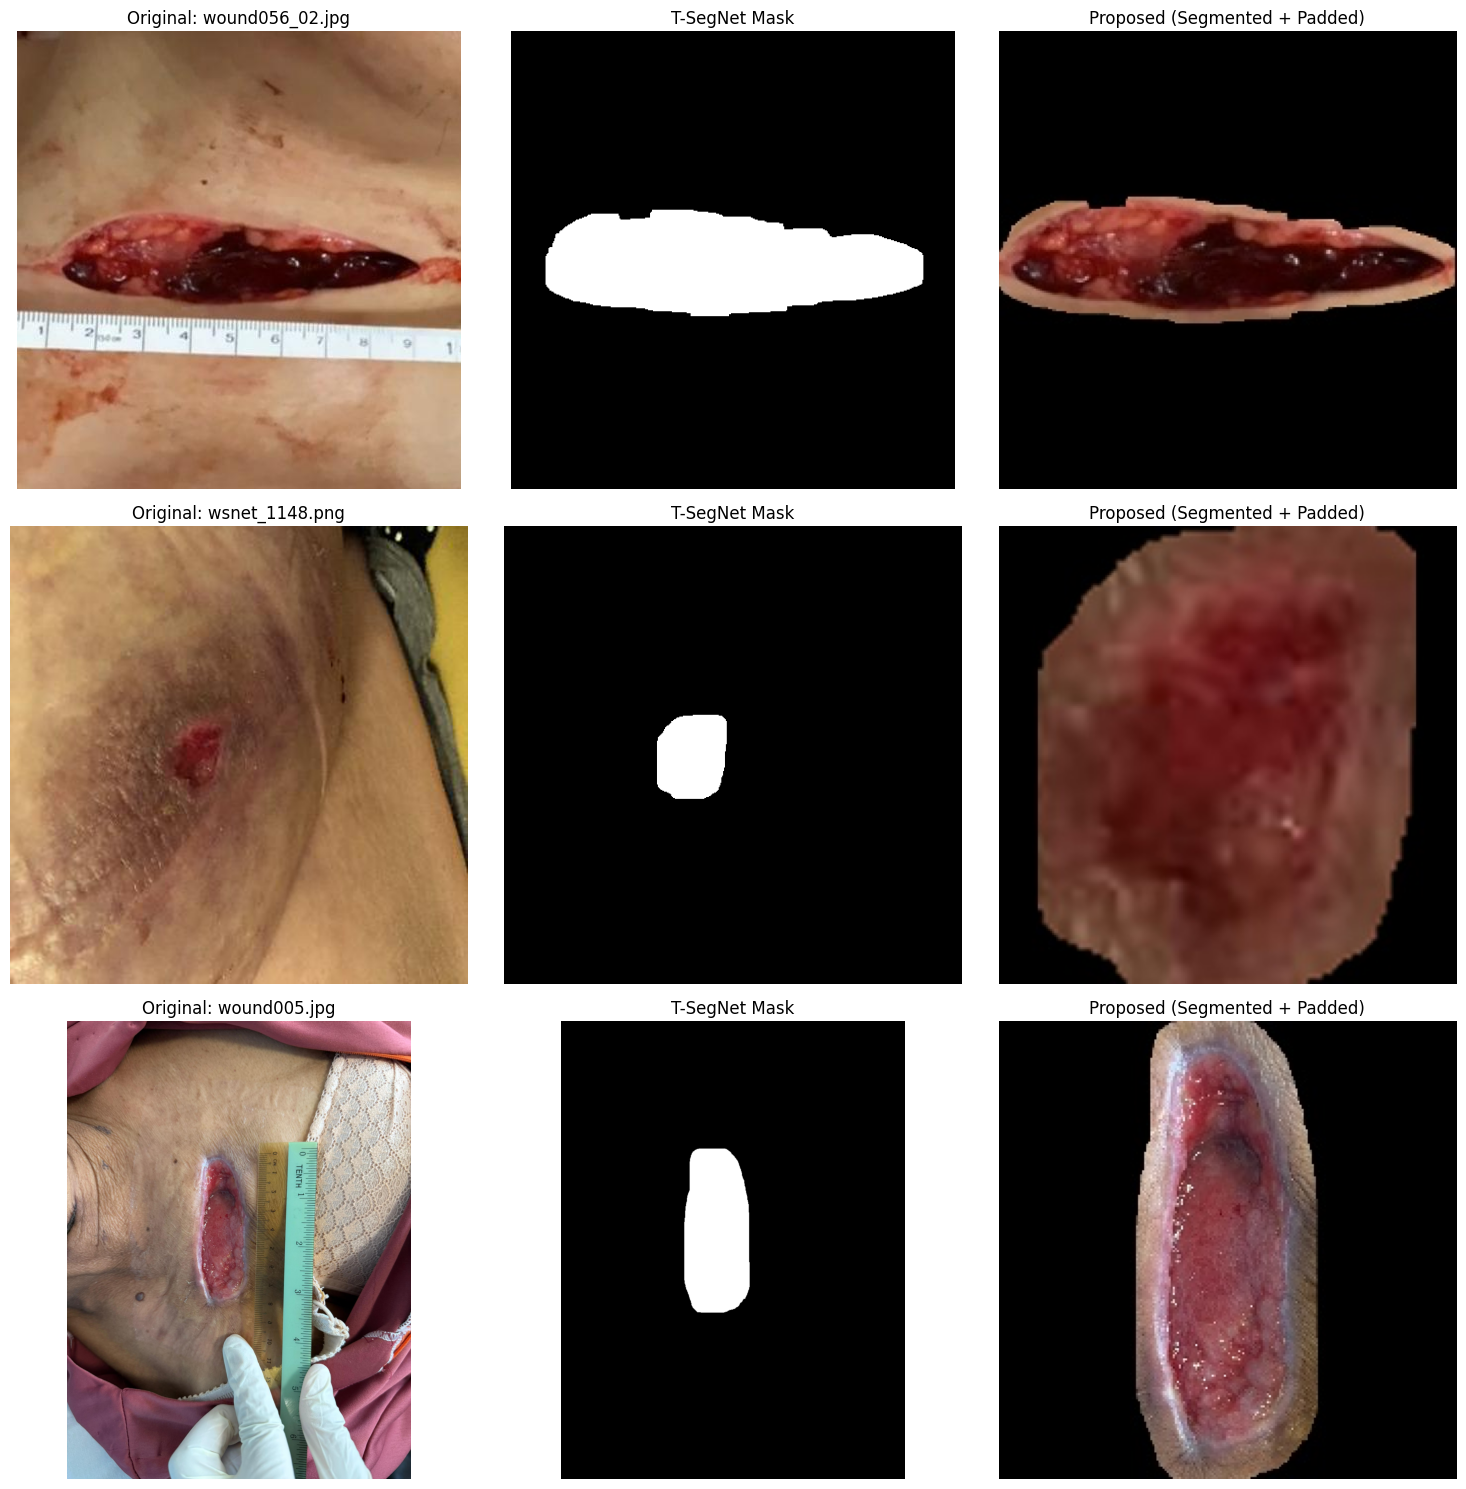

In [6]:
# IMPROVED VISUAL VERIFICATION
def verify_preprocessing_clean(df, n=3):
    # Get files that exist in processed folder
    processed_files = [f for f in os.listdir(PROPOSED_IMG_DIR) if f.endswith(('.jpg', '.png'))]
    valid_df = df[df['filename'].isin(processed_files)]

    if len(valid_df) == 0:
        print("No processed images found in the folder.")
        return

    sample_size = min(n, len(valid_df))
    sample = valid_df.sample(sample_size)

    fig, axes = plt.subplots(sample_size, 3, figsize=(15, 5 * sample_size))
    if sample_size == 1:
        axes = np.expand_dims(axes, axis=0)

    for i, (idx, row) in enumerate(sample.iterrows()):
        filename = row['filename']
        base_name = os.path.splitext(filename)[0]

        # SEARCH FOR ORIGINAL IMAGE
        raw_path = None
        for folder in [PUBLIC_IMG_DIR, PRIVATE_IMG_DIR]:
            for ext in ['.png', '.jpg']:
                temp_path = os.path.join(folder, base_name + ext)
                if os.path.exists(temp_path):
                    raw_path = temp_path
                    break
            if raw_path: break

        mask_path = os.path.join(MASK_DIR, base_name + '.png')
        proc_path = os.path.join(PROPOSED_IMG_DIR, filename)

        # Plotting
        try:
            # Load Original
            if raw_path:
                axes[i, 0].imshow(plt.imread(raw_path))
                axes[i, 0].set_title(f"Original: {os.path.basename(raw_path)}")
            else:
                axes[i, 0].set_title("Original Not Found")

            # Load Mask
            axes[i, 1].imshow(plt.imread(mask_path), cmap='gray')
            axes[i, 1].set_title("T-SegNet Mask")

            # Load Processed
            axes[i, 2].imshow(plt.imread(proc_path))
            axes[i, 2].set_title("Proposed (Segmented + Padded)")

        except Exception as e:
            print(f"Could not load {filename}: {e}")

        for j in range(3):
            axes[i, j].axis('off')

    plt.tight_layout()
    plt.show()

# Run the clean check
verify_preprocessing_clean(df, n=3)